# <center> **PHYSICAL ACTIVITY RECOGNITION**

In this competition, we will develop a **classifier** designed to recognize various types of physical activities using data collected from the accelerometer and gyroscope sensors in smartphones. Both of these sensors measure different aspects of movement and orientation.

> The data for this competition was gathered from **30 volunteers**, aged 19 to 48 years. These volunteers wore smartphones on their waist while performing a set of activities, including six basic activities: three **static postures** (**standing**, **sitting**, and **lying**), and three **dynamic activities** (**walking**, **walking downstairs**, and **walking upstairs**). The experiment also involved transitions between these activities, which include **stand-to-sit**, **sit-to-stand**, **sit-to-lie**, **lie-to-sit**, **stand-to-lie**, and **lie-to-stand**.
>
> The dataset comprises **3-axial linear acceleration** and **3-axial angular velocity** measurements collected at a constant rate of **50Hz**. The experiments were video-recorded, and the activities were manually labeled.
>
> The collected dataset was randomly divided into **two sets**, with 70% of the volunteers contributing to the **training data**, and the remaining 30% contributing to the **test data**.

To begin building our **classifier**, we will load the necessary packages and import our data.

In [63]:
# Loading packages
library(tidyverse) 
library(dplyr)
library(readr)
library(caret)
library(nnet)

# Creating a path to the files
list.files(path = "../input") 

# Coping all files to the working directory
system(paste0("cp -r ", list.files("../input", pattern = "recognition", full.names=TRUE), "/* ./"))

# List files in the current working directory
list.files()

[1] "physical-activity-recognition-bda-2023"

[1] "activity_labels.txt"    "example_submission.csv" "RawData"               
[4] "README.txt"             "Rplot001.png"

# **1. READING THE DATA**


The data used for this competition is stored in text (.txt) files. These files contain the signals for each user during each experiment (trial; 3 trials per person). Additionally, there is a text file that contains the **activity labels** corresponding to segments of signals for all participants in each experiment.

**In this section, we will:**
> *   Import the activity labels.
> *   Examine the samples.
> *   Import and visualize the signals.
> *   Merge our data and visualize the merged data.


## **1.1 IMPORT ACTIVITY LABELS**

In this first part, we will load these activity labels. As previously mentioned, there are 12 activities in total (three static activities, three dynamic activities, and six transition activities)

In [64]:
# Read the text file containing the activity labels
act_labels = read_delim("activity_labels.txt"," ",col_names=FALSE,trim_ws=TRUE) 
act_labels = act_labels %>% select(X1,X2)
act_labels

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 12 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: " "
chr  (1): X2
dbl  (1): X1
lgl (11): X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


X1,X2
<dbl>,<chr>
1,WALKING
2,WALKING_UPSTAIRS
3,WALKING_DOWNSTAIRS
4,SITTING
5,STANDING
6,LAYING
7,STAND_TO_SIT
8,SIT_TO_STAND
9,SIT_TO_LIE


## **1.2 SAMPLES** 

The **signals** are also stored in text files, each containing three columns. Each column represents the signal measured in one of the three channels of the sensor (these channels correspond to the X, Y, and Z directions). These signals consist of sequences of measurements, referred to as **samples**.

> For each subject, the file **labels.txt** contains information such as the **trial number** (trial), **user ID** (userid), the **activity along with the sample number where the activity started** (start), and the **sample number where the activity ended** (end).

To begin, we will **import the training data** and assign names to the columns. Subsequently, we will associate the labels with the activities to create a data frame that records the sample number where each activity started and ended within the signal files.

In [65]:
# Loading the signals from the training data and adding column names
labels = read_delim("./RawData/Train/labels_train.txt", " ", col_names = F)
colnames(labels) <- c('trial', 'userid', 'activity', 'start', 'end')

# Matching the labels with the activites
labels = labels %>% mutate(activity = act_labels$X2[activity])

# Look at our new dataframe
print(labels)

Rows: 849 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: " "
dbl (5): X1, X2, X3, X4, X5

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 849 × 5
   trial userid activity     start   end
   <dbl>  <dbl> <chr>        <dbl> <dbl>
 1     1      1 STANDING       250  1232
 2     1      1 STAND_TO_SIT  1233  1392
 3     1      1 SITTING       1393  2194
 4     1      1 SIT_TO_STAND  2195  2359
 5     1      1 STANDING      2360  3374
 6     1      1 STAND_TO_LIE  3375  3662
 7     1      1 LAYING        3663  4538
 8     1      1 LIE_TO_SIT    4539  4735
 9     1      1 SITTING       4736  5667
10     1      1 SIT_TO_LIE    5668  5859
# ℹ 839 more rows


We can observe that for each participant, there are multiple files, which aligns with the understanding that each participant performed various activities as per the protocol. We have labeled each of the **samples** with the corresponding activity. Each row provides information on the samples where an activity started and ended for a particular participant in a given experimental run.

However, it would be more convenient to have a data frame that assigns an activity label to each trial, user ID, and time sample ID, with matching rows for each row in the signals data frame.

> We can achieve this by using a **nifty feature** – allowing cells in a tibble to contain a **list()**. This is particularly useful for storing groups of values that all share the same values in other variables. Tibbles with such cells are referred to as **"nested."**

Let's proceed to create such a **nested tibble.**

In [67]:
# Add the sequence start:end to each row in a list, creating a nester tibble
sample_labels_nested = 
    labels %>% 
    rowwise() %>% # do next operation(s) rowwise
    mutate(sampleid = list(start:end)) %>%
    ungroup()

# Check the resulting table
print(sample_labels_nested)

# A tibble: 849 × 6
   trial userid activity     start   end sampleid     
   <dbl>  <dbl> <chr>        <dbl> <dbl> <list>       
 1     1      1 STANDING       250  1232 <int [983]>  
 2     1      1 STAND_TO_SIT  1233  1392 <int [160]>  
 3     1      1 SITTING       1393  2194 <int [802]>  
 4     1      1 SIT_TO_STAND  2195  2359 <int [165]>  
 5     1      1 STANDING      2360  3374 <int [1,015]>
 6     1      1 STAND_TO_LIE  3375  3662 <int [288]>  
 7     1      1 LAYING        3663  4538 <int [876]>  
 8     1      1 LIE_TO_SIT    4539  4735 <int [197]>  
 9     1      1 SITTING       4736  5667 <int [932]>  
10     1      1 SIT_TO_LIE    5668  5859 <int [192]>  
# ℹ 839 more rows


The column **sampleid** still appears somewhat abstract. The numbers enclosed in square brackets indicate how many **integers** are present in the corresponding row.

Our next step is to **unnest** the tibble. This will yield a table that associates the correct **activity** with each **sampleid**.

However, it's not as straightforward as it sounds. Some activities, like **WALKING**, were performed multiple times in the same experiment but in different time segments. It's crucial to differentiate between these segments of **WALKING**. To accomplish this, before unnesting, we will add row numbers as **segment identifiers**.

In [68]:
# Unnest the nested tabel.
sample_labels = 
    sample_labels_nested %>% 

    # Rows are segments, we need to keep track of different segements
    mutate(segment = row_number() ) %>% 

    # Expand the data frame to one sample per row
    unnest(cols = c(sampleid)) %>% 

    # Remove columns we don't need anymore
    select(-start, -end) 

# Check the result (first few rows are not interesting; rows 977-990 are)
print(sample_labels[0:1000, ])

# A tibble: 1,000 × 5
   trial userid activity sampleid segment
   <dbl>  <dbl> <chr>       <int>   <int>
 1     1      1 STANDING      250       1
 2     1      1 STANDING      251       1
 3     1      1 STANDING      252       1
 4     1      1 STANDING      253       1
 5     1      1 STANDING      254       1
 6     1      1 STANDING      255       1
 7     1      1 STANDING      256       1
 8     1      1 STANDING      257       1
 9     1      1 STANDING      258       1
10     1      1 STANDING      259       1
# ℹ 990 more rows


## **1.3 IMPORT SIGNALS**

Let's proceed with importing the signals. To illustrate this process, we'll begin by examining the data for a participant with **userid = 1** and **trial = 1**. We'll demonstrate how to import the signals and assign activity labels to each sample based on the information stored in the **labels** data frame.

### **1.3.1 ACCELEROMETER DATA**

We'll initiate this process with the accelerometer data. 

> `The units used for the accelerations (both total and body) are 'g's, which represent the gravity of Earth (approximately 9.80665 m/s²)`.

We'll identify the file containing the accelerometer data and extract the **participant ID** (stored as: username) and the **experimental trial** (stored as: expname).

Next, we'll create a plot displaying the samples recorded for the first participant. In this plot, we'll visualize the **signals** recorded in the X, Y, and Z directions. You'll notice distinct patterns associated with different activities in this plot.

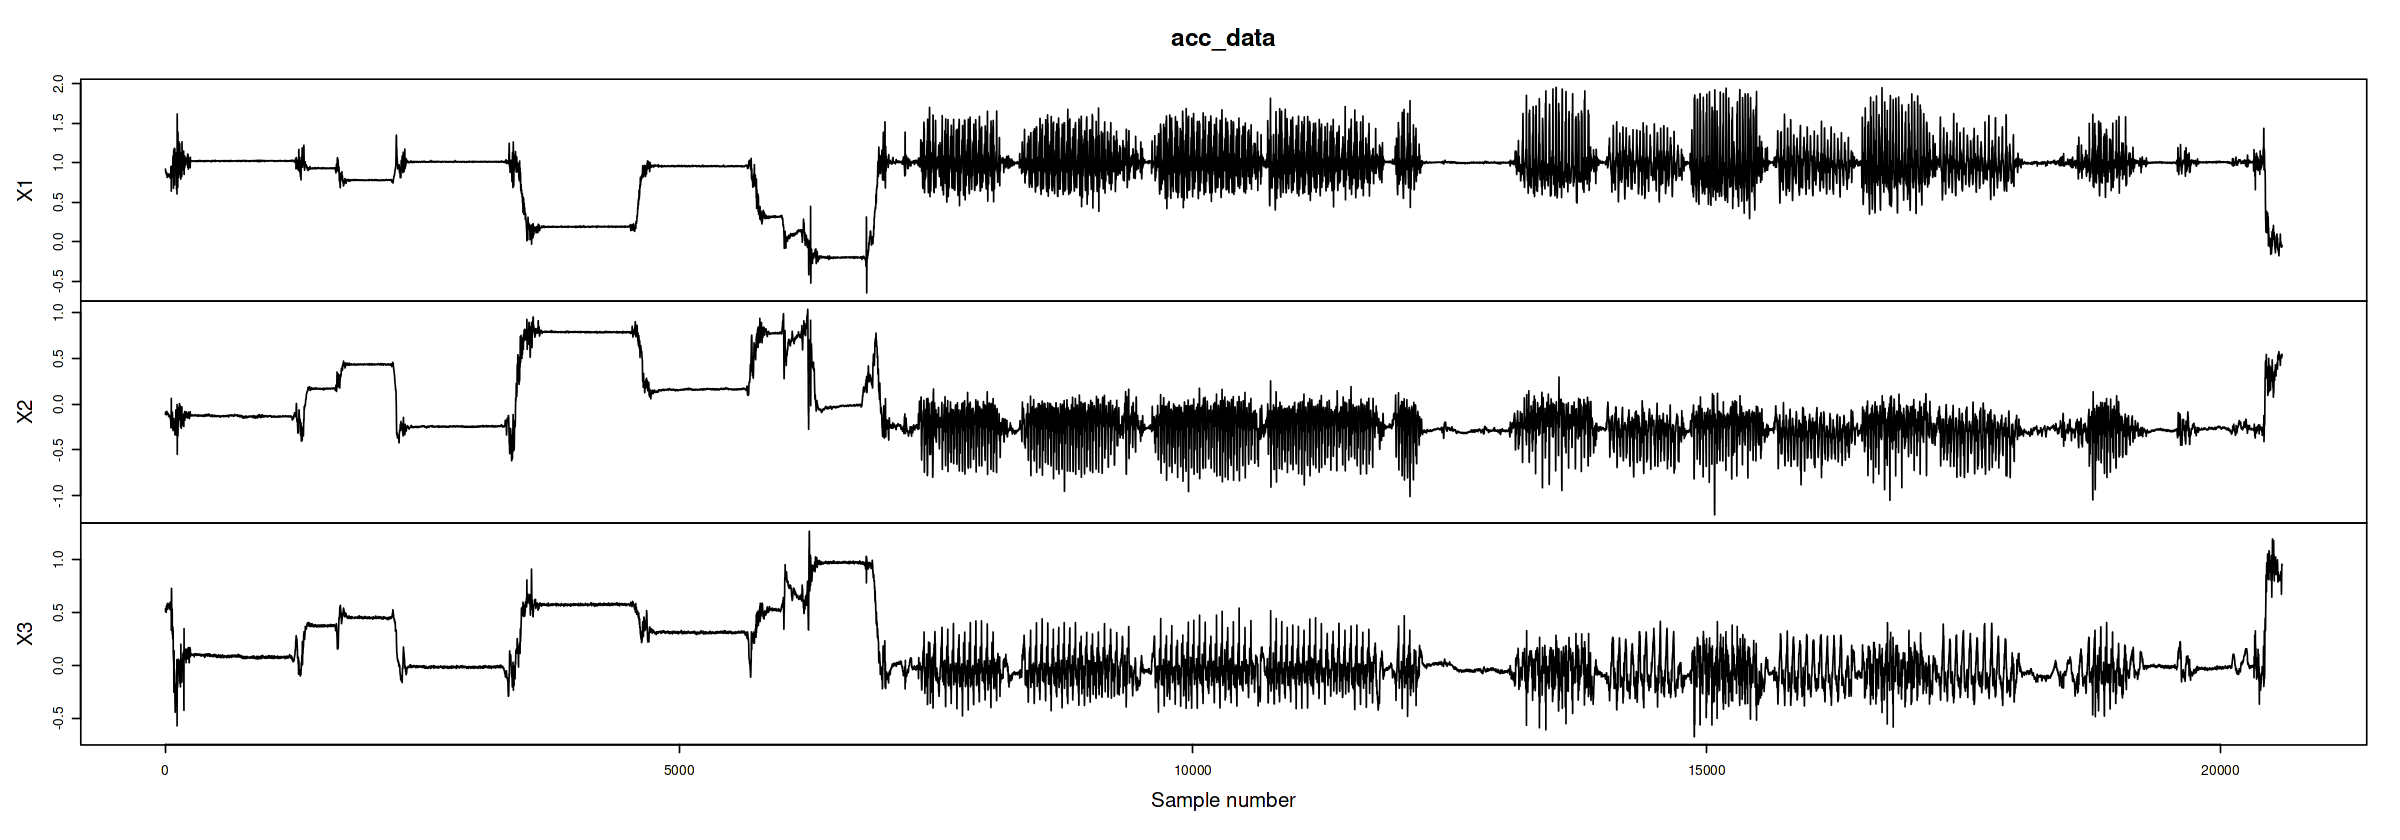

In [69]:
# Identify the file name and extract the 'username' (participant ID) and 'expname' (experimental trial)
filename_acc = "RawData/Train/acc_exp01_user01.txt"
username = gsub(".+user(\\d+).+", "\\1", filename_acc) %>% as.integer()
expname  = gsub(".+exp(\\d+).+", "\\1", filename_acc) %>% as.integer()

# Import the data from the file
acc_data = read.delim(filename_acc, " ", header = FALSE) %>%
  setNames(c("X1", "X2", "X3"))

# Creating a plot
options(repr.plot.width=20)
plot.ts(acc_data, xlab="Sample number")

### **1.3.2 GYROSCOPE DATA**

Now, let's take a look at the **gyroscope** data. Similar to what we did with the accelerometer data, we will identify the file containing the gyroscope data and extract the **participant ID** (stored as: username) and the **experimental trial** (stored as: expname).

> `The units used for gyroscope measurements are in radians per second (rad/s)`.

We'll proceed by creating a plot displaying the samples recorded for the first participant. In this plot, we will visualize the **signals** recorded in the X, Y, and Z directions. However, you may notice that the patterns you saw in the accelerometer data are not as apparent.

> To understand why the plots look different, we need to grasp the fundamental difference between an accelerometer and a gyroscope. Accelerometers measure **linear acceleration**, providing information about how quickly something is speeding up or slowing down. It helps determine if something is moving forward or backward, or if its speed is increasing or decreasing. On the other hand, a **gyroscope** measures **angular velocity**, helping us understand how something is rotating or spinning. It provides information about whether something is turning left or right or spinning at varying speeds.

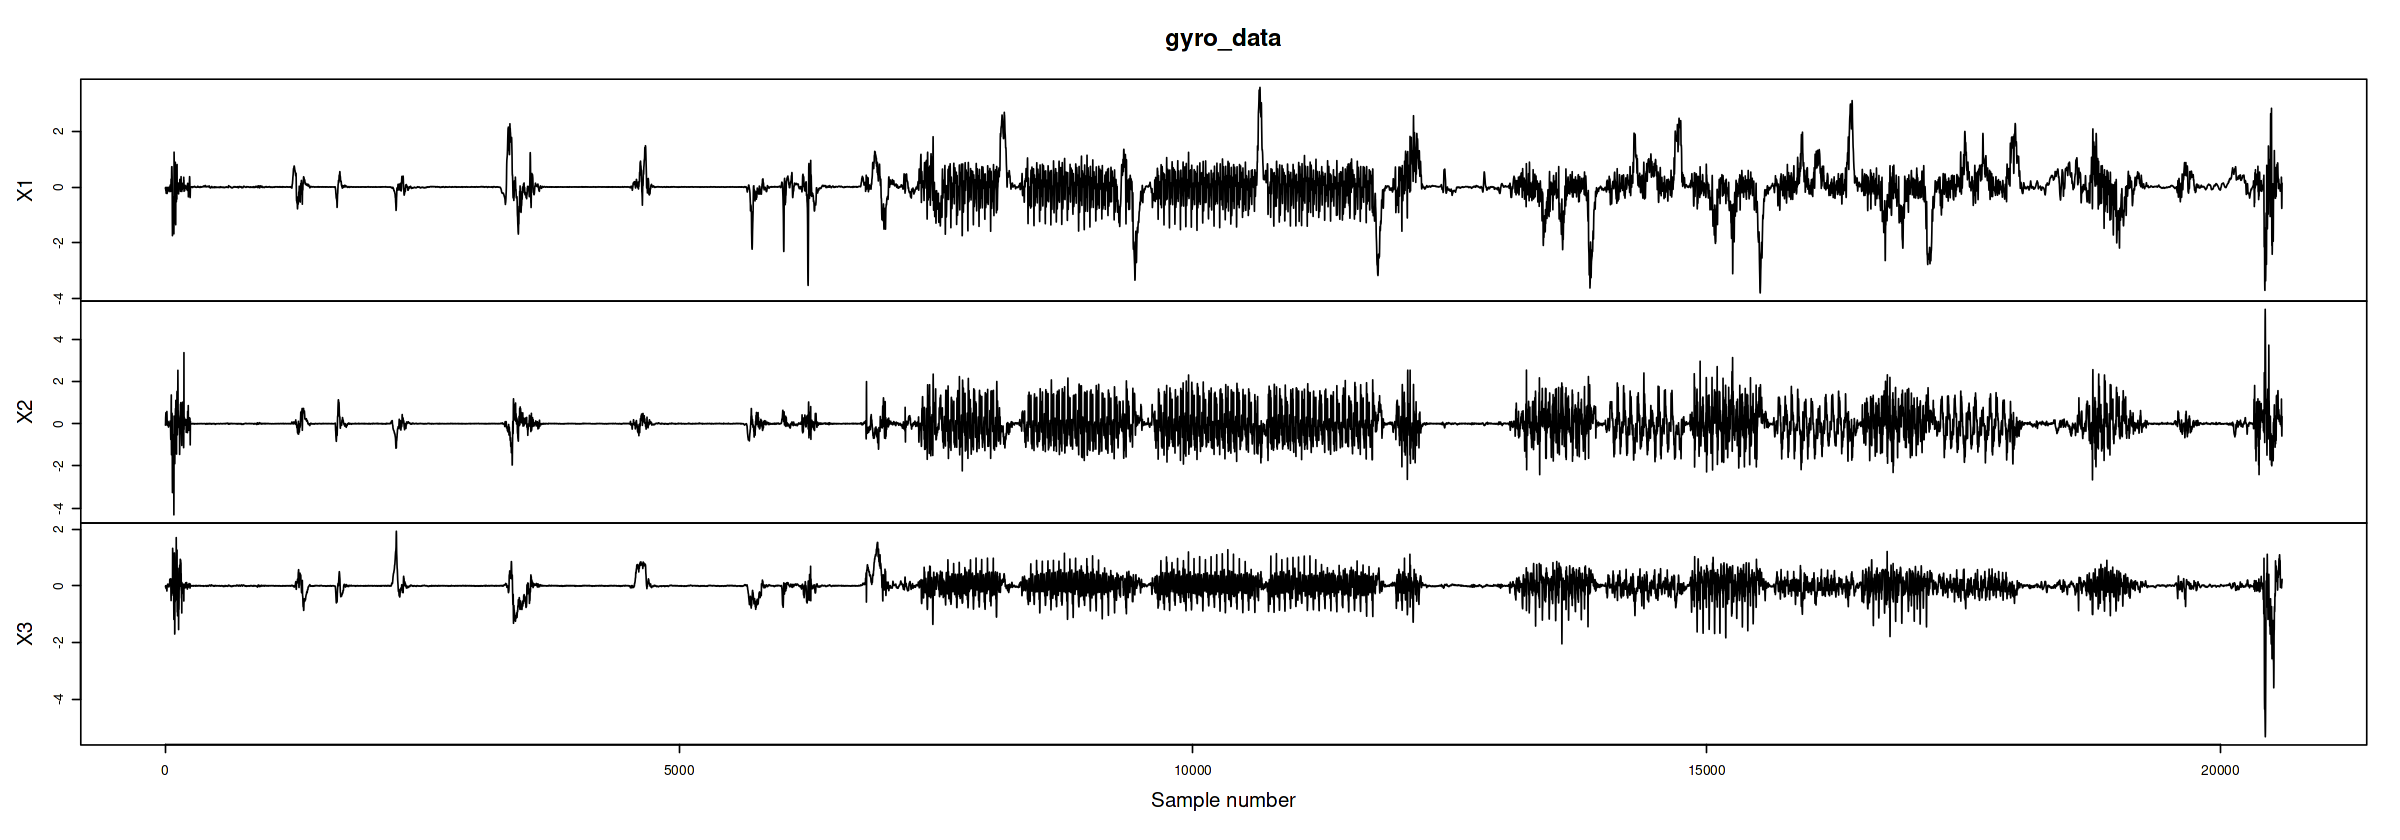

In [70]:
# Identify the file name and extract the 'username' (participant ID) and 'expname' (experimental trial)
filename_gyro = "RawData/Train/gyro_exp01_user01.txt"
username = gsub(".+user(\\d+).+", "\\1", filename_gyro) %>% as.integer()
expname  = gsub(".+exp(\\d+).+", "\\1", filename_gyro) %>% as.integer()

# Read gyro_data and give names to variables
gyro_data <- read.delim(filename_gyro, " ", header = FALSE) %>%
  setNames(c("X1", "X2", "X3"))

# Creating a plot
options(repr.plot.width=20)
plot.ts(gyro_data, xlab="Sample number")

## **1.4 MERGE DATA**

Having examined both the **gyroscope** and **accelerometer** data, our next task is to merge them. By merging the **signals** with the **sample labels**, we can determine the activity associated with each observation.

In [71]:
# Combine accelometer and gyroscope data
combined_data <- cbind(acc_data, gyro_data)

# Store signals of the first participant for both acc and gyro data in a data frame, with 'userid' and 'trial'
user_df = 
    data.frame(userid = username, trial = expname, combined_data) %>%
    mutate(sampleid = 0:(nrow(combined_data)-1) ) %>%
    left_join(sample_labels) 

# Check the result (first few rows are not interesting; the following are)
print(user_df[1227:1239, ])

Joining with `by = join_by(userid, trial, sampleid)`


     userid trial       X1         X2         X3         X1.1        X2.1
1227      1     1 1.022222 -0.1375000 0.07500000 -0.007941248 0.001832596
1228      1     1 1.019445 -0.1347222 0.07361111 -0.014355334 0.011301007
1229      1     1 1.022222 -0.1375000 0.07777778 -0.015271631 0.014966198
1230      1     1 1.025000 -0.1375000 0.07638889 -0.013133603 0.041844271
1231      1     1 1.030556 -0.1444445 0.07916667 -0.034819320 0.076663591
1232      1     1 1.016667 -0.1430556 0.05833334 -0.006108652 0.032986723
1233      1     1 1.015278 -0.1416667 0.05972222  0.031459559 0.003359759
1234      1     1 1.020833 -0.1638889 0.05555556  0.072998397 0.033903021
1235      1     1 1.027778 -0.1736111 0.06944445  0.103847094 0.064140849
1236      1     1 1.025000 -0.1638889 0.05833334  0.103847094 0.045204028
1237      1     1 1.022222 -0.1472222 0.04861111  0.130114302 0.033292156
1238      1     1 1.022222 -0.1597222 0.04305556  0.192727983 0.013744468
1239      1     1 1.027778 -0.1625000 

### **1.4.1 ILLUSTRATING MERGED ACCELEROMETER DATA**

Do you remember the specific patterns we noticed in the accelerometer data during our initial examination? Now that we have merged our data with the **sample labels**, we can investigate which pattern corresponds to each activity.

> In the plot, you'll see gray lines crossing through it. These gray traces represent non-labeled segments (**NAs**), indicating activities that are not on the list. However, for the moment, we won't dwell too much on these missing values.

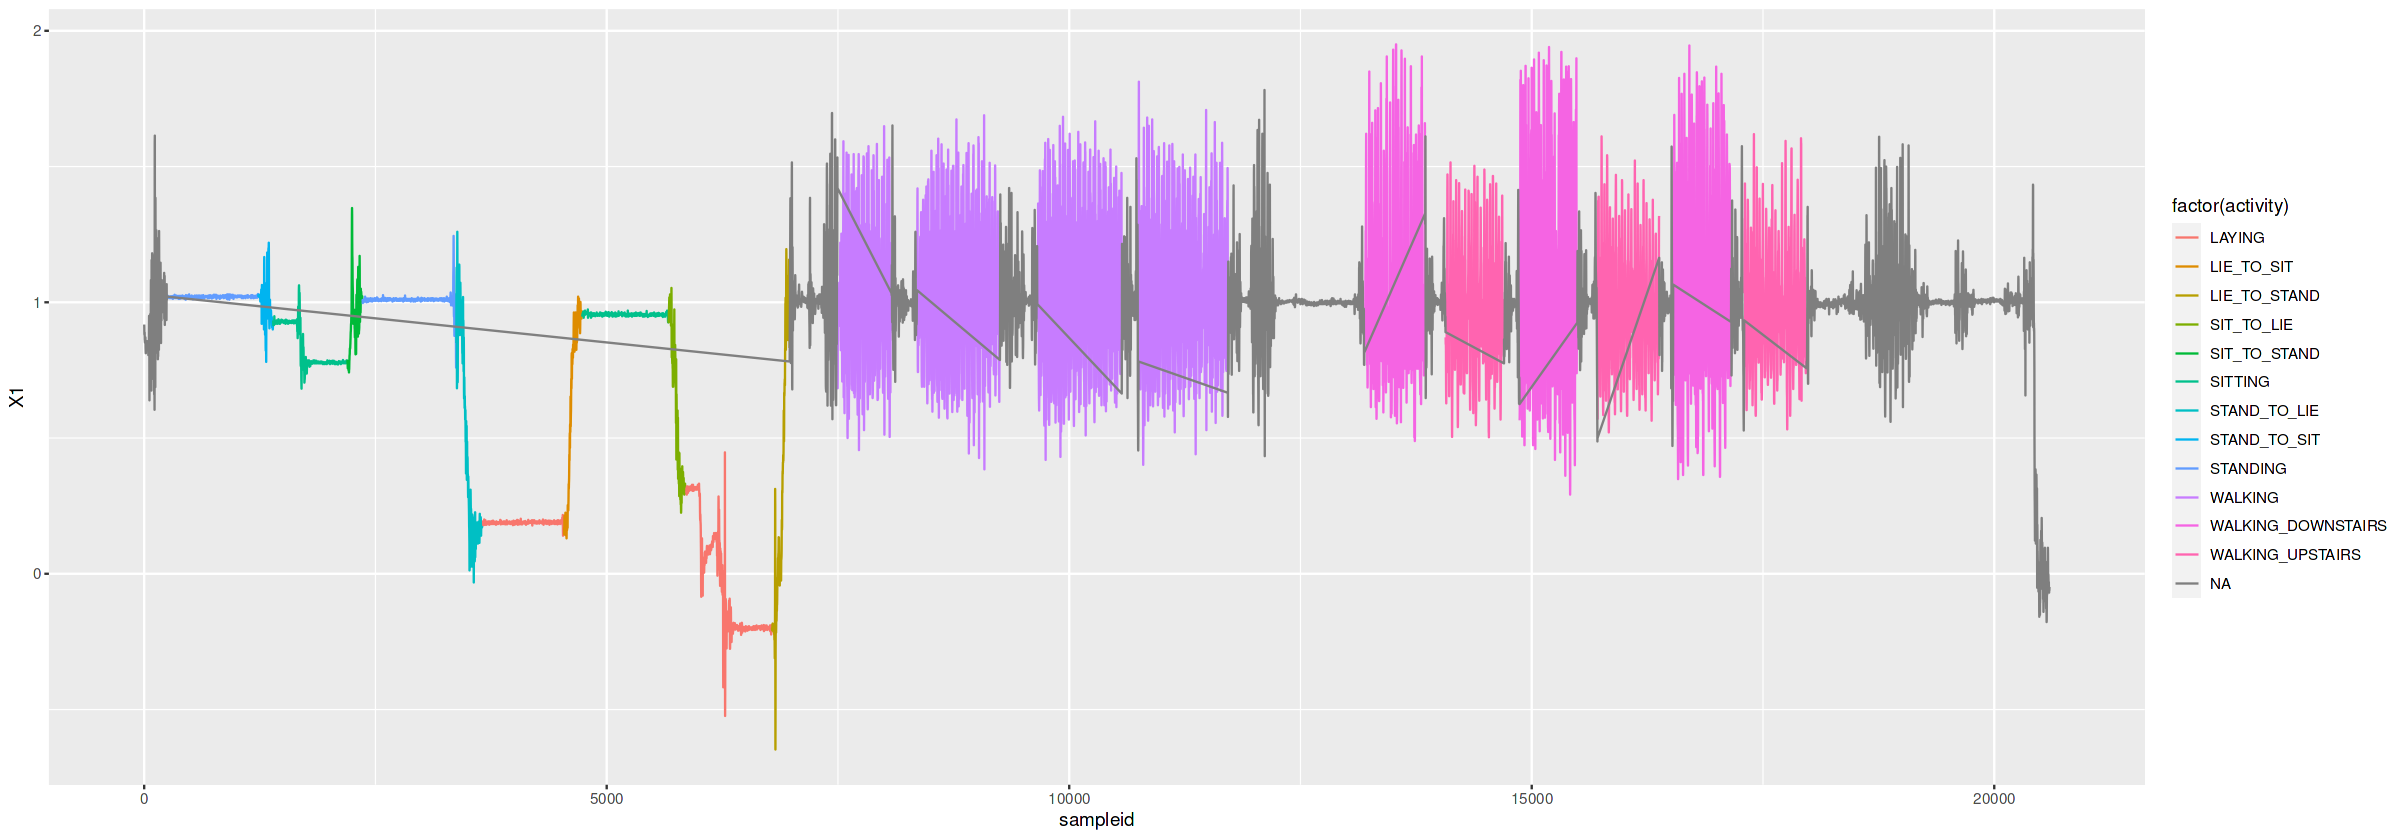

In [72]:
# Set plot width options for the visualization
options(repr.plot.width=20) 

# Create a ggplot visualization using user_df data
user_df %>%
  ggplot(aes(x = sampleid, y = X1, col = factor(activity), group = segment)) + 

# Add a line plot to the ggplot visualization
  geom_line()

### **1.4.2 ILLUSTRATING MERGED GYROSCOPE DATA**

Identifying patterns in the **gyroscope** data was a bit more challenging. However, with our data now merged with the **sample labels**, it becomes somewhat easier to discern which pattern corresponds to each activity.

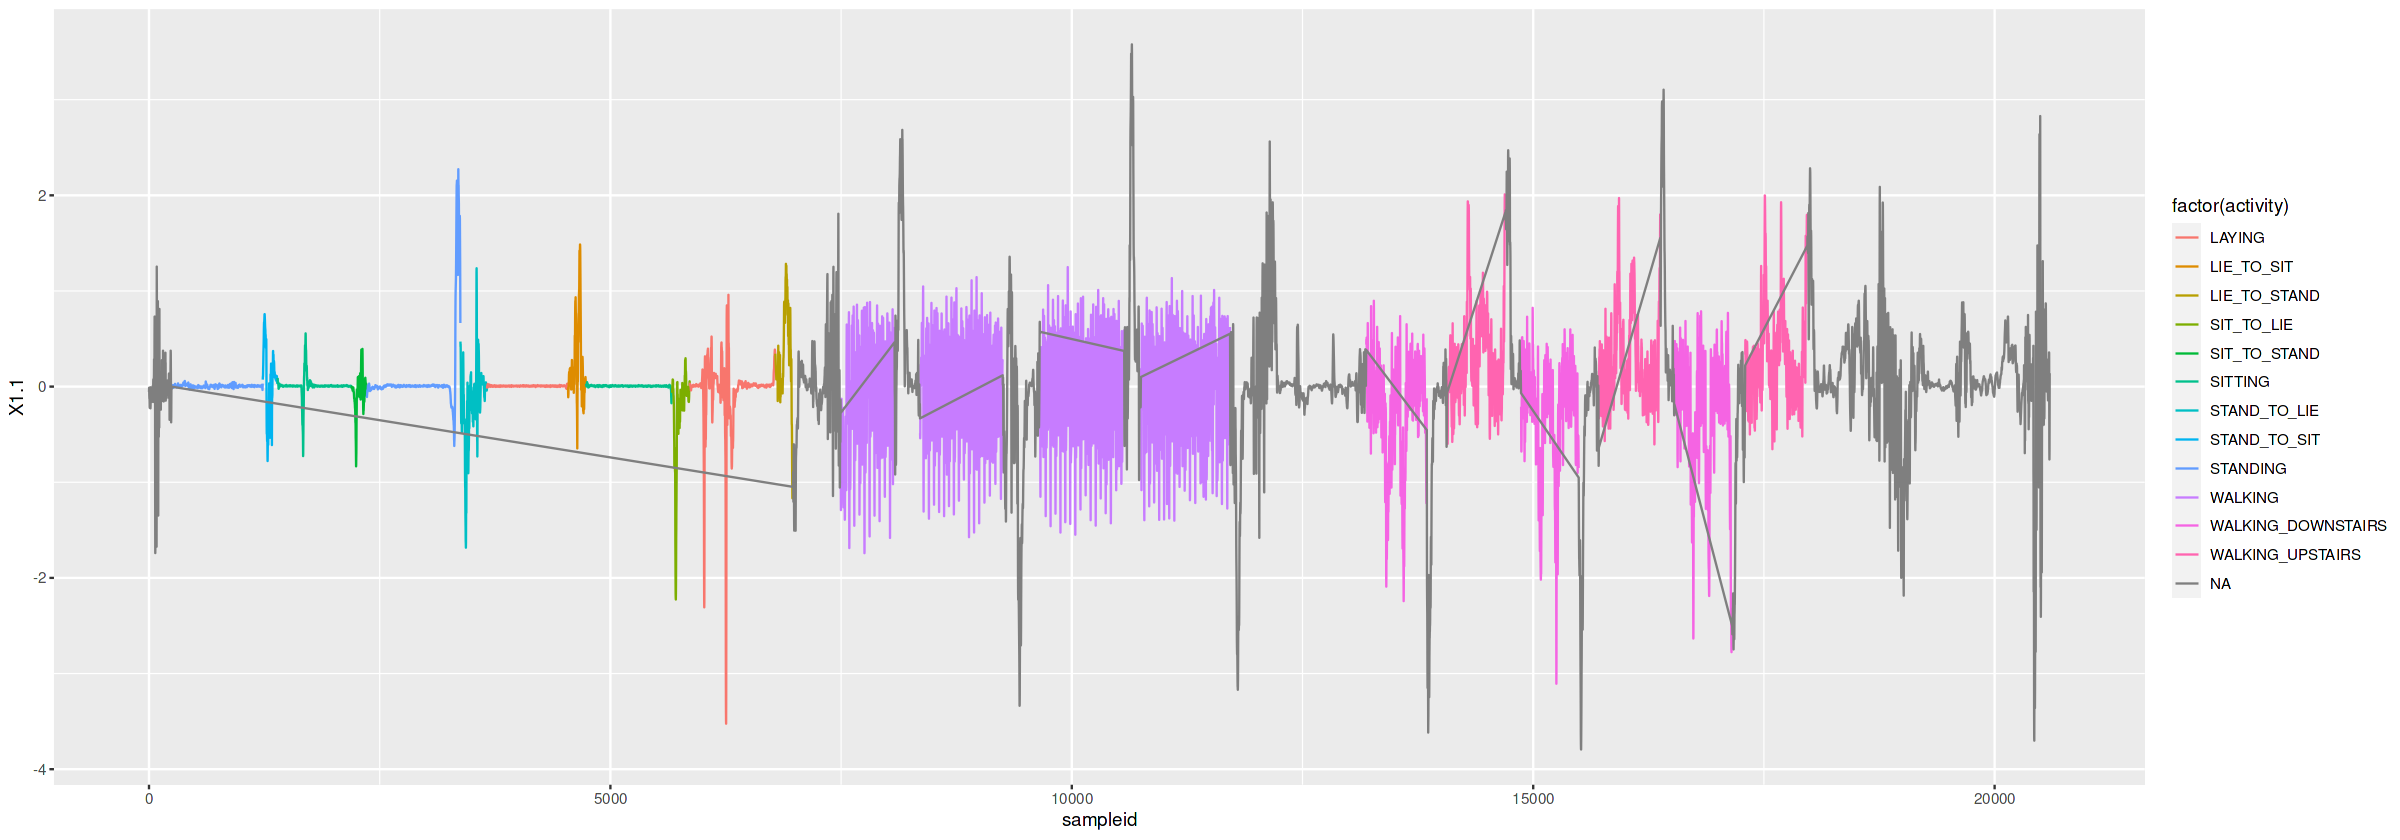

In [73]:
# Set plot width options for the visualization
options(repr.plot.width=20) 

# Create a ggplot visualization using user_df data
user_df %>%
  ggplot(aes(x = sampleid, y = X1.1, col = factor(activity), group = segment)) + 

# Add a line plot to the ggplot visualization
  geom_line()

# **2. FEATURE EXTRACTION**

With all our data consolidated into a single table, we are now ready to extract **features** that can be utilized for our classification.

**In this section, we will:**

> * Create epochs.
> * Extract features.

## **2.1 EPOCHS**

For the classification algorithms we plan to use, the individual time samples themselves are not particularly useful as features. This is because:

`we don't know how long the typical pattern for a certain activity is.`

Therefore, our objective is to divide the samples into smaller segments known as **epochs**.

> **For this competition, we were tasked with predicting the activities within epochs, each consisting of 128 samples (which corresponds to 2.56 seconds at a 50Hz sampling rate).**

To achieve this, we will divide the sample numbers by 128, resulting in an integer that groups samples into epochs, and we will assign an **epoch ID**. While doing so, we can also compute the **means** for all our **Xs** (representing the signals).

Now, armed with these epochs, we can proceed to compute various types of features.

In [74]:
# Split data into epochs and add epoch ID
user_df %>%
  mutate(epoch = sampleid %/% 128) %>% 
  group_by(epoch) %>%
  head(5)

userid,trial,X1,X2,X3,X1.1,X2.1,X3.1,sampleid,activity,segment,epoch
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<int>,<dbl>
1,1,0.9180556,-0.11250000,0.5097223,-0.05497787,-0.06963864,-0.030848695,0,NA,NA,0
1,1,0.9111111,-0.09305556,0.5375000,-0.01252274,0.01924226,-0.038484510,1,NA,NA,0
1,1,0.8819445,-0.08611111,0.5138889,-0.02351831,0.27641651,0.006414085,2,NA,NA,0
1,1,0.8819445,-0.08611111,0.5138889,-0.09346239,0.36774087,0.001221730,3,NA,NA,0
1,1,0.8791667,-0.10000000,0.5055556,-0.12431107,0.47678033,-0.022907447,4,NA,NA,0


## **2.2 FEATURE EXTRACTION USING FUNCTIONS**

In the upcoming section, we will extract features that necessitate the creation of functions to compute them.

### **2.2.1 LAGGED CROSS CORRELATION**

One of the time-domain features we will explore is the **lagged cross correlation**. It quantifies the **similarity or relationship between two signals while considering a time lag**. This feature provides valuable insights into how one signal correlates with another when one of the signals is temporally shifted.

In [75]:
# Lagged cor feature
lagged_cor = function(x, y=x, lag=0) {
   lagged_cor = cor(x, dplyr::lag(y, lag), use='pairwise')
    return(lagged_cor)
}

### **2.2.2 SKEWNESS AND KURTOSIS**

Another set of features we will explore includes **skewness** and **kurtosis**. These features assess the **shape and distribution** of amplitude values within a signal. They offer insights into the asymmetry, tail behavior, and "peakiness" of a signal's amplitude distribution (Zhu et al., 2017).

In [76]:
# Skewness feature
skewness <- function(x) {
  n <- length(x)
  mean_x <- mean(x, na.rm = TRUE)
  s <- sqrt(sum((x - mean_x)^2, na.rm = TRUE) / (n - 1))
  skewness <- sum(((x - mean_x) / s)^3, na.rm = TRUE) / n
  return(skewness)
}

# Kurtosis feature
kurtosis <- function(x) {
  n <- length(x)
  mean_x <- mean(x, na.rm = TRUE)
  s <- sqrt(sum((x - mean_x)^2, na.rm = TRUE) / (n - 1))
  kurtosis <- sum(((x - mean_x) / s)^4, na.rm = TRUE) / n - 3
  return(kurtosis)
}

### **2.2.3 ENERGY**

**Energy** serves as another significant feature frequently employed in signal processing. It offers insights into the **overall magnitude or intensity of a signal** within a particular time window or interval (Grasman,2018). This metric is calculated by summing the squares of signal values within the specified time interval.

In [77]:
# Energy feature
energy = function(x) {
  mean(x^2)
}

### **2.2.4 SPECTRAL FEATURES**

The **spectral mean** is a valuable metric for characterizing the central or average frequency content within a signal's spectrum. It helps identify the dominant or central frequency around which a signal is concentrated.

To assess the dispersion or spread of frequency components within a signal's frequency spectrum, we can compute the **spectral variance**. This feature provides insights into how frequencies are distributed around the mean frequency, offering a glimpse into the spectral characteristics of the signal.

Analyzing the **spectral peak** is a valuable technique in signal processing. The spectral peak represents the frequency at which a signal has its maximum amplitude in the frequency domain, also known as the fundamental frequency (Grasman,2018).

In [78]:
# Spectral mean
spe_mean <- function(var) {
    spec <- spectrum(var, plot = FALSE)
    df <- spec$freq[2] - spec$freq[1]
    spe_mean <- sum(spec$freq * spec$spec * df)
    return(spe_mean)
}

# Spectral variance
spe_var <- function(var) {
    spec <- spectrum(var, plot = FALSE)
    df <- spec$freq[2] - spec$freq[1]
    spe_var <- sum((spec$freq - mean(var))^2 * spec$spec * df)
    return(spe_var)
}

# Spectral peak frequency function
spectral_peak = function(x) {
  spec = spectrum(x, plot = FALSE) 
  peak = spec$freq[which.max(spec$spec)]
  return(peak)                      
}


### **2.2.5 MOST COMMON VALUE**

The **most common value** feature, as demonstrated in the quickstart notebook for this competition, is another noteworthy metric we can utilize. This feature helps identify the value that appears most frequently within a signal, offering insights into prevalent patterns or trends within the data.

In [79]:
# Most common value feature
most_common_value = function(x) {
    counts = table(x, useNA='no')
    most_frequent = which.max(counts)
    return(names(most_frequent))
}

### **2.2.6 MAGNITUDE AS ROOT MEAN SQUARE**

The **root mean square** (RMS) is another important feature (Zhu et al., 2017). Similar to power and energy, RMS provides insights into the magnitude of a vector. It helps characterize the overall amplitude or strength of a signal, offering valuable information about signal intensity.

In [80]:
# Magnitude feature
rms <- function(x){
  sqrt((1/length(x)*(sum(x^2))))
}

# **3. PUTTING IT ALL TOGETHER**

Up until now, we've developed several functions for processing a single file. Our next step is to apply these functions to all the relevant files and combine the resulting data frames into a comprehensive one.

**In this section, we will:**

> * List our raw files.
> * Utilize our feature functions.
> * Merge our data.

To initiate this process, we'll compile a list of all our raw data files containing the training data. We will then load both the accelerometer data and the gyroscope data.

In [81]:
# Listing all raw data files
list.files("./RawData/Train/", pattern = "^acc")
list.files("./RawData/Train/", pattern = "^gyro")

[1] "acc_exp01_user01.txt" "acc_exp02_user01.txt" "acc_exp05_user03.txt"
 [4] "acc_exp06_user03.txt" "acc_exp09_user05.txt" "acc_exp10_user05.txt"
 [7] "acc_exp11_user06.txt" "acc_exp12_user06.txt" "acc_exp13_user07.txt"
[10] "acc_exp14_user07.txt" "acc_exp15_user08.txt" "acc_exp16_user08.txt"
[13] "acc_exp22_user11.txt" "acc_exp23_user11.txt" "acc_exp28_user14.txt"
[16] "acc_exp29_user14.txt" "acc_exp30_user15.txt" "acc_exp31_user15.txt"
[19] "acc_exp32_user16.txt" "acc_exp33_user16.txt" "acc_exp34_user17.txt"
[22] "acc_exp35_user17.txt" "acc_exp38_user19.txt" "acc_exp39_user19.txt"
[25] "acc_exp42_user21.txt" "acc_exp43_user21.txt" "acc_exp44_user22.txt"
[28] "acc_exp45_user22.txt" "acc_exp46_user23.txt" "acc_exp47_user23.txt"
[31] "acc_exp50_user25.txt" "acc_exp51_user25.txt" "acc_exp52_user26.txt"
[34] "acc_exp53_user26.txt" "acc_exp54_user27.txt" "acc_exp55_user27.txt"
[37] "acc_exp56_user28.txt" "acc_exp57_user28.txt" "acc_exp58_user29.txt"
[40] "acc_exp59_user29.txt" "acc_exp60_user30.txt" "acc_exp61_user30.txt"

[1] "gyro_exp01_user01.txt" "gyro_exp02_user01.txt" "gyro_exp05_user03.txt"
 [4] "gyro_exp06_user03.txt" "gyro_exp09_user05.txt" "gyro_exp10_user05.txt"
 [7] "gyro_exp11_user06.txt" "gyro_exp12_user06.txt" "gyro_exp13_user07.txt"
[10] "gyro_exp14_user07.txt" "gyro_exp15_user08.txt" "gyro_exp16_user08.txt"
[13] "gyro_exp22_user11.txt" "gyro_exp23_user11.txt" "gyro_exp28_user14.txt"
[16] "gyro_exp29_user14.txt" "gyro_exp30_user15.txt" "gyro_exp31_user15.txt"
[19] "gyro_exp32_user16.txt" "gyro_exp33_user16.txt" "gyro_exp34_user17.txt"
[22] "gyro_exp35_user17.txt" "gyro_exp38_user19.txt" "gyro_exp39_user19.txt"
[25] "gyro_exp42_user21.txt" "gyro_exp43_user21.txt" "gyro_exp44_user22.txt"
[28] "gyro_exp45_user22.txt" "gyro_exp46_user23.txt" "gyro_exp47_user23.txt"
[31] "gyro_exp50_user25.txt" "gyro_exp51_user25.txt" "gyro_exp52_user26.txt"
[34] "gyro_exp53_user26.txt" "gyro_exp54_user27.txt" "gyro_exp55_user27.txt"
[37] "gyro_exp56_user28.txt" "gyro_exp57_user28.txt" "gyro_exp58_user29.txt"
[40] "gyro_exp59_user29.txt" "gyro_exp60_user30.txt" "gyro_exp61_user30.txt"

## **3.1 FEATURE FUNCTION**

We are now prepared to extract all the features. Here is an outline of the steps involved:

> 1. Extract user and experimental IDs.
> 2. Import sensor signals and merge them with the labels.
> 3. Create epochs and assign an epoch ID.

Now, we'll proceed to extract our features and inspect the results to confirm that everything has worked as expected! 

Note that besides the features for which we previously created functions, there are several other features that we will extract with our feature function. These features are **basic statistics** (such as mean, median,range, etc.) that we extracted as we believe they may add some insights into the characteristics of the dataset.

In [82]:
# Feature function
extractFeatures <- function(filename, sample_labels) {
    
    # Extract user and experimental run ID's from file name
    username = gsub(".+user(\\d+).+", "\\1", filename) %>% as.numeric()
    expname  = gsub( ".+exp(\\d+).+", "\\1", filename) %>% as.numeric()
    
    # Import the sensor signals from the file
    user01 <- read_delim(filename, " ", col_names = F, progress = TRUE, 
                 col_types = "ddd")
    
    # Merge signals with labels 
    user_df <- 
        data.frame(userid = username, trial = expname, user01) %>%
        mutate(sampleid = 0:(nrow(user01)-1) ) %>%
        left_join(sample_labels, by = c('userid','trial','sampleid')) 
    
    # Split in epochs of 128 samples and compute features per epoch
    usertimedom <-  user_df %>%
    
          # Add an epoch ID variable (on epoch = 2.56 sec)
          mutate(epoch = sampleid %/% 128) %>% 

          # Extract statistical features from each epoch
          group_by(epoch) %>%
          summarise(
            # Keep track of user and experiment information
            user_id = username, 
            exp_id = expname,   
              
            # Epoch's activity labels and start sample
            activity = most_common_value(c("-", activity)),
            sampleid = sampleid[1],
              
            # Adding Features  ---------------------------
            # Mean
            m1 = mean(X1), 
            m2 = mean(X2),
            m3 = mean(X3), 
              
            # Mean difference
            mdif1_2 = m1 - m2, 
            mdif1_3 = m1 - m3,
            mdif2_3 = m2 - m3,
            
            # Minimum
            min1 = min(X1),
            min2 = min(X2),
            min3 = min(X3),
              
            # Maximum
            max1 = max(X1),
            max2 = max(X2),
            max3 = max(X3),
              
            # Standard deviation
            sd1 = sd(X1), 
            sd2 = sd(X2), 
            sd3 = sd(X3), 
      
            # Median
            median1 = median(X1),
            median2 = median(X2),
            median3 = median(X3),
              
            # Range
            range1 = max(X1) - min (X1),
            range2 = max(X2) - min (X2),
            range3 = max(X3) - min (X3),
            
            # 25th percentile
            q1_25 = quantile(X1, .25),
            q2_25 = quantile(X2, .25),
            q3_25 = quantile(X3, .25),
            
            # 50th percentile
            q1_50 = quantile(X1, .50),
            q2_50 = quantile(X2, .50),
            q3_50 = quantile(X3, .50),
              
            # 75th percentile
            q1_75 = quantile(X1, .75),
            q2_75 = quantile(X2, .75),
            q3_75 = quantile(X3, .75),
            
            # Autocorrelation for X1(t1) and X1(t2) etc.
            AR1.1 = cor(X1, lag(X1), use = "pairwise"),
            AR1.2 = cor(X1, lag(X1, n = 2), use = "pairwise"),
            AR2.1 = cor(X1, lag(X2), use = "pairwise"),
            AR2.2 = cor(X1, lag(X2, n = 2), use = "pairwise"),
            AR3.1 = cor(X1, lag(X3), use = "pairwise"),
            AR3.2 = cor(X1, lag(X3, n = 2), use = "pairwise"),
        
            # Cross-lagged correlation for X1(t1) and X2(t0) etc.
            AR12.1 = cor(X1, lag(X2), use = "pairwise"),
            AR12.2 = cor(X1, lag(X2), use = "pairwise"),
            AR13.1 = cor(X1, lag(X2), use = "pairwise"),
            AR13.2 = cor(X1, lag(X2), use = "pairwise"),
            AR23.1 = cor(X1, lag(X2), use = "pairwise"),
            AR23.2 = cor(X1, lag(X2), use = "pairwise"),
              
            # Skewness
            skew1 = e1071::skewness(X1),
            skew2 = e1071::skewness(X2),
            skew3 = e1071::skewness(X3),
              
            # Kurtosis
            kurt1 = e1071::kurtosis(X1),
            kurt2 = e1071::kurtosis(X2),
            kurt3 = e1071::kurtosis(X3),
      
            # Energy
            energy_1 = mean(X1^2),
            energy_2 = mean(X2^2),
            energy_3 = mean(X3^2),
              
            # Spectral mean
            spec_mean_1 = spe_mean(X1),
            spec_mean_2 = spe_mean(X2),
            spec_mean_3 = spe_mean(X3),
              
            # Spectral variance
            spec_var_1 = spe_var(X1),
            spec_var_2 = spe_var(X2),
            spec_var_3 = spe_var(X3),
                            
            # Spectral peak
            spectral_peak1 = spectral_peak(X1),
            spectral_peak2 = spectral_peak(X2),
            spectral_peak3 = spectral_peak(X3),
                            
            # RMS
            rms_1 = rms(X1),
            rms_1 = rms(X2),
            rms_1 = rms(X3),
              
            n_samples = n()  
          ) 
    
    usertimedom 
}


# Loading both acc and gyro data ---------------------------
filename_acc <- dir("./RawData/Train/", "^acc", full.names = TRUE)
filename_gyro <- dir("./RawData/Train/", "^gyro", full.names = TRUE)

# Using map_dfr to run the function `extractFeatures` on all elements
myData_acc = map_dfr(filename_acc, extractFeatures, sample_labels)
myData_gyro = map_dfr(filename_gyro, extractFeatures, sample_labels)

# Check the results
print(myData_acc)
print(myData_gyro)

# A tibble: 6,252 × 67
   epoch user_id exp_id activity sampleid    m1     m2     m3 mdif1_2 mdif1_3
   <dbl>   <dbl>  <dbl> <chr>       <int> <dbl>  <dbl>  <dbl>   <dbl>   <dbl>
 1     0       1      1 -               0 0.909 -0.165 0.252     1.07   0.657
 2     1       1      1 STANDING      128 1.02  -0.132 0.0509    1.15   0.965
 3     2       1      1 STANDING      256 1.02  -0.124 0.0987    1.14   0.920
 4     3       1      1 STANDING      384 1.02  -0.125 0.0926    1.15   0.927
 5     4       1      1 STANDING      512 1.02  -0.130 0.0851    1.15   0.935
 6     5       1      1 STANDING      640 1.02  -0.129 0.0850    1.15   0.936
 7     6       1      1 STANDING      768 1.02  -0.138 0.0739    1.16   0.947
 8     7       1      1 STANDING      896 1.02  -0.131 0.0765    1.15   0.945
 9     8       1      1 STANDING     1024 1.02  -0.136 0.0750    1.16   0.946
10     9       1      1 STANDING     1152 1.02  -0.129 0.0925    1.15   0.927
# ℹ 6,242 more rows
# ℹ 57 more variables

## **3.2 COMBINING ACC AND GYRO FEATURES**

In this step, we will merge the data from the gyroscope and accelerometer datasets. 

In [90]:
# Create a combined dataset
myData <-  myData_acc %>%
    left_join(myData_gyro, by = c("user_id", "exp_id", "activity", "sampleid", "epoch", "n_samples"))

# Print the combined dataset
head(myData)

# #Check dim
dim(myData)

epoch,user_id,exp_id,activity,sampleid,m1.x,m2.x,m3.x,mdif1_2.x,mdif1_3.x,⋯,spec_mean_1.y,spec_mean_2.y,spec_mean_3.y,spec_var_1.y,spec_var_2.y,spec_var_3.y,spectral_peak1.y,spectral_peak2.y,spectral_peak3.y,rms_1.y
<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,1,1,-,0,0.908941,-0.1649089,0.25218100,1.073850,0.6567600,⋯,1.597967e-02,3.941905e-02,1.764163e-02,1.014774e-02,4.497898e-02,4.245081e-03,0.0156250,0.0078125,0.0468750,0.518407957
1,1,1,STANDING,128,1.015723,-0.1324110,0.05088976,1.148134,0.9648329,⋯,1.200725e-03,2.435418e-02,3.629848e-03,2.736837e-04,4.224565e-03,9.422170e-04,0.0625000,0.0546875,0.0234375,0.316900721
2,1,1,STANDING,256,1.019217,-0.1241102,0.09873047,1.143327,0.9204862,⋯,3.785223e-06,2.675050e-06,3.296914e-06,6.570965e-07,8.137783e-07,1.000899e-06,0.0312500,0.0156250,0.0078125,0.006480723
3,1,1,STANDING,384,1.020074,-0.1254232,0.09264323,1.145497,0.9274306,⋯,5.830368e-06,4.833804e-06,4.049781e-06,7.517440e-07,1.298793e-06,7.509417e-07,0.0312500,0.0234375,0.0078125,0.011226791
4,1,1,STANDING,512,1.020172,-0.1297960,0.08509115,1.149968,0.9350804,⋯,5.064767e-06,4.562142e-06,3.406414e-06,8.908834e-07,1.117966e-06,7.320533e-07,0.0078125,0.0312500,0.0312500,0.009186572
5,1,1,STANDING,640,1.020757,-0.1285590,0.08496094,1.149316,0.9357965,⋯,4.914521e-06,3.769410e-06,4.274318e-06,8.420718e-07,8.804029e-07,7.971838e-07,0.0312500,0.0781250,0.0546875,0.014473497


[1] 6252  128

## **3.3 CLEANING THE DATA**

Now that we have our final dataset in the correct format, it's almost time to fit some models. However, before proceeding, let's clean our data.

**Our objective is to eliminate redundant variables, so we will check for:**

> * NA values
> * Variables with near-zero variation
> * Highly correlated variables

### **3.3.1 NA VALUES**

Do you recall how we observed **NA values for activity** in the gyroscope and accelerometer data for the first participant during visualization? Let's handle those now.

> Typically, we would remove NA values using **!is.na**, but in this case, observations not associated with one of the activities are marked as **"-"** to denote missing values. Therefore, we will use **!= "-"** to filter them out.

Further we also decided to exclude all epochs that are not at a length of 128, as it feels a bit like comparing apples to pears otherwise. We see that that reduced our observations to 4900.

In [91]:
# Remove rows with NA values
myData1 <- myData[myData$activity != "-", ]

# Remove rows with epoch not 128
myData2 <- myData1 %>% filter(n_samples == 128)

# Check dim
dim(myData2)

[1] 4900  128

### **3.3.2 VARIABLES WITH NEAR-ZERO VARIATION**

Variables with **near-zero variation** tend to add complexity to our models without contributing much information. Including them can potentially lead to overfitting. As a result, it's important to identify and remove these variables.

In [92]:
# Coloums we want to keep
drop.cols <- c("epoch", "user_id", "exp_id", "activity", "sampleid", "n_samples")
check_data <- myData2 %>% 
            select(-one_of(drop.cols))

# Check whether any predictors are at or near zero variance
nzv <- nearZeroVar(check_data)
nzv_names <- colnames(check_data)[nzv]
nzv_names

# Remove any predictors near zero variance
myData3 <- myData2 %>% 
    select(-one_of(nzv_names))

# Check dim
dim(myData3)

character(0)

[1] 4900  128

### **3.3.3 HIGHLY CORRELATED VARIABLES**

In the next phase, we aim to pinpoint highly correlated variables. This process helps us establish a more stable and interpretable model.

To identify these highly correlated features, we'll create a dataframe containing only numeric values. Subsequently, we will utilize the **caret** package to detect highly correlated values. Finally, we will eliminate the highly correlated variables from our dataset.

In [86]:
# Create a dataframe containing only numeric values
myData3_num <- myData3 %>% select_if(is.numeric)

# Remove constant variables
myData3_num <- myData3_num %>% 
  select(-where(~ sd(.) == 0))

# Check for missing values
if (anyNA(myData3_num)) {
  myData3_num <- myData3_num %>% na.omit()  # This removes rows with missing values
}

# Calculate the correlation matrix
R <- cor(myData3_num, use = "pairwise.complete.obs")

# Specify the variables to keep
variables_to_keep <- c("epoch", "user_id", "exp_id", "activity", "sampleid", "n_samples")

# Identify the indices of variables to remove based on high correlation
cor_indices <- caret::findCorrelation(R, cutoff = 0.8)  

# Find the variable names to remove, excluding the specified variables to keep
vars_to_remove <- names(myData3_num)[cor_indices]
vars_to_remove <- setdiff(vars_to_remove, variables_to_keep)

# Remove the highly correlated variables from myData2
myData4 <- myData3 %>% select(-one_of(vars_to_remove))

# Check the resulting dataset
head(myData4)

# Check dim
dim(myData4)

epoch,user_id,exp_id,activity,sampleid,mdif2_3.x,max2.x,max3.x,q1_25.x,AR1.2.x,⋯,energy_3.y,spec_mean_1.y,spec_mean_2.y,spec_mean_3.y,spec_var_1.y,spec_var_2.y,spec_var_3.y,spectral_peak1.y,spectral_peak2.y,spectral_peak3.y
<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1,STANDING,128,-0.1833008,0.005555556,0.34722224,0.9861112,0.064119281,⋯,1.004261e-01,1.200725e-03,2.435418e-02,3.629848e-03,2.736837e-04,4.224565e-03,9.422170e-04,0.0625000,0.0546875,0.0234375
2,1,1,STANDING,256,-0.2228407,-0.115277783,0.10972223,1.0180556,-0.135593631,⋯,4.199977e-05,3.785223e-06,2.675050e-06,3.296914e-06,6.570965e-07,8.137783e-07,1.000899e-06,0.0312500,0.0156250,0.0078125
3,1,1,STANDING,384,-0.2180664,-0.108333336,0.10972223,1.0180556,-0.005905649,⋯,1.260408e-04,5.830368e-06,4.833804e-06,4.049781e-06,7.517440e-07,1.298793e-06,7.509417e-07,0.0312500,0.0234375,0.0078125
4,1,1,STANDING,512,-0.2148872,-0.118055555,0.10138889,1.0180556,-0.132593922,⋯,8.439310e-05,5.064767e-06,4.562142e-06,3.406414e-06,8.908834e-07,1.117966e-06,7.320533e-07,0.0078125,0.0312500,0.0312500
5,1,1,STANDING,640,-0.2135200,-0.111111120,0.10416667,1.0194445,0.178460566,⋯,2.094821e-04,4.914521e-06,3.769410e-06,4.274318e-06,8.420718e-07,8.804029e-07,7.971838e-07,0.0312500,0.0781250,0.0546875
6,1,1,STANDING,768,-0.2124024,-0.125000002,0.09027778,1.0194445,-0.058692423,⋯,7.809171e-05,3.424867e-06,3.047141e-06,2.725354e-06,6.472644e-07,6.346981e-07,6.838516e-07,0.0234375,0.0703125,0.0078125


[1] 4900   59

### **3.3.4 VARIABLES NOT SUITABLE FOR PREDICTION**

As we see our dataframe still contains variables that we can not use for predictions such as **epoch, user_id, exp_id, sampleid**, and **n_sample**. We will remove them now and then start our model selection.

In [87]:
# Creating a new dataframe only including the classes to predict and the predictors
cleaned_data <-  myData4 %>%
    select(-epoch, -user_id, -exp_id, -sampleid, -n_samples)

# Visualizing the clean data
head(cleaned_data)

# Check dim
dim(cleaned_data)

activity,mdif2_3.x,max2.x,max3.x,q1_25.x,AR1.2.x,AR2.2.x,AR3.1.x,skew1.x,skew2.x,⋯,energy_3.y,spec_mean_1.y,spec_mean_2.y,spec_mean_3.y,spec_var_1.y,spec_var_2.y,spec_var_3.y,spectral_peak1.y,spectral_peak2.y,spectral_peak3.y
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
STANDING,-0.1833008,0.005555556,0.34722224,0.9861112,0.064119281,0.085554567,-0.03499456,-0.07560850,-0.03534337,⋯,1.004261e-01,1.200725e-03,2.435418e-02,3.629848e-03,2.736837e-04,4.224565e-03,9.422170e-04,0.0625000,0.0546875,0.0234375
STANDING,-0.2228407,-0.115277783,0.10972223,1.0180556,-0.135593631,-0.005873311,-0.10414516,0.01030481,-0.16029915,⋯,4.199977e-05,3.785223e-06,2.675050e-06,3.296914e-06,6.570965e-07,8.137783e-07,1.000899e-06,0.0312500,0.0156250,0.0078125
STANDING,-0.2180664,-0.108333336,0.10972223,1.0180556,-0.005905649,-0.007810915,-0.14667653,-0.37654877,0.42325422,⋯,1.260408e-04,5.830368e-06,4.833804e-06,4.049781e-06,7.517440e-07,1.298793e-06,7.509417e-07,0.0312500,0.0234375,0.0078125
STANDING,-0.2148872,-0.118055555,0.10138889,1.0180556,-0.132593922,0.064557081,-0.09294806,-0.28076432,0.07004263,⋯,8.439310e-05,5.064767e-06,4.562142e-06,3.406414e-06,8.908834e-07,1.117966e-06,7.320533e-07,0.0078125,0.0312500,0.0312500
STANDING,-0.2135200,-0.111111120,0.10416667,1.0194445,0.178460566,-0.230092431,-0.32227365,-0.03199556,-0.97726258,⋯,2.094821e-04,4.914521e-06,3.769410e-06,4.274318e-06,8.420718e-07,8.804029e-07,7.971838e-07,0.0312500,0.0781250,0.0546875
STANDING,-0.2124024,-0.125000002,0.09027778,1.0194445,-0.058692423,-0.103462750,0.01222745,-0.09266163,-0.37172185,⋯,7.809171e-05,3.424867e-06,3.047141e-06,2.725354e-06,6.472644e-07,6.346981e-07,6.838516e-07,0.0234375,0.0703125,0.0078125


[1] 4900   54

# **4. BUILDING MODELS**

Now it's time to train models using the remaining predictors in our dataset.

**For this competition, we have chosen to employ the following models:**
> * Multinomial logistic regression
> * Linear discriminant analysis
> * K-nearest neighbors
> * standardized K-nearest neighbors

To assess the model performance accurately on unseen data, we utilized a combination of cross-validation with the caret package and a hold-out set. Cross-validation was employed to fine-tune the models, while the hold-out set, constituting 20% of the training data, was reserved for later accuracy evaluation.


In [88]:
# Cross validate our models using 10 folds
trcntr <- trainControl('cv', number = 10, p = 0.8)

## **4.1. MULTINOMIAL LOGISTIC REGRESSION**

The first model we constructed was a **Multinomial Logistic Regression**. This technique allows us to predict outcomes across various categories by modeling the intricate relationships between our input features and the **likelihood of each class**.

In [89]:
# Fitting Multinomial logistic regression
fit_multinom = caret::train(activity ~ ., data = cleaned_data, 
                       method = "multinom", 
                       trControl = trcntr, 
                       MaxNWts = 1500, 
                       verbose = FALSE, 
                       trace = FALSE)
# Storing Results
fit_multinom$result

,decay,Accuracy,Kappa,AccuracySD,KappaSD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0e+00,0.8904028,0.8718951,0.011619118,0.013624341
2,1e-04,0.8906178,0.8721476,0.011429757,0.013395675
3,1e-01,0.8924445,0.8741821,0.008213072,0.009669994


## **4.2. LINEAR DISCRIMINANT ANALYSIS**

The subsequent model we developed was **Linear Discriminant Analysis (LDA)**, selected to extract the most discriminative information from our training data. LDA is a powerful technique for dimensionality reduction and classification.

In [93]:
# Fitting LDA
fit_lda <- caret::train(activity ~., data = cleaned_data, 
                        method = 'lda', 
                        trControl = trcntr)
# Storing Results
fit_lda$result

,parameter,Accuracy,Kappa,AccuracySD,KappaSD
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,none,0.8640917,0.8411544,0.01615548,0.01888035


## **4.3. K-NEAREST NEIGHBORS**

Following Linear Discriminant Analysis, we employed a **K-Nearest Neighbors (KNN) classifier** as the next step in our modeling approach. KNN is a more flexible and intuitive method for pattern recognition and classification tasks.

In [94]:
# FittingkNN 
fit_knn = caret::train(activity ~ ., data = cleaned_data, 
                       method="knn", 
                       trControl = trcntr)
# Storing Results
fit_knn$result

,k,Accuracy,Kappa,AccuracySD,KappaSD
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,5,0.7391782,0.6934371,0.02120219,0.02501264
2,7,0.7404040,0.6947158,0.02018013,0.02379809
3,9,0.7393599,0.6932666,0.01485224,0.01759701


## **4.4. STANDARDIZED K-NEAREST NEIGHBORS**

In this model, we implement a **standardized k-Nearest Neighbors (KNN) classifier**. Standardization of the data is adopted to ensure consistent feature scaling, allowing the KNN algorithm to be more flexibile.

In [95]:
# Fitting KNN
fit_KNN1 <- caret::train(activity ~ ., data = cleaned_data, 
                       method = "knn", 
                       trControl = trcntr,
                       preProcess = "scale",
                       metric = "Accuracy")
# Storing Results
fit_KNN1$results

,k,Accuracy,Kappa,AccuracySD,KappaSD
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,5,0.8793736,0.8588036,0.014675466,0.01720100
2,7,0.8789608,0.8582581,0.009870772,0.01159560
3,9,0.8781528,0.8572684,0.013123999,0.01544385


## **4.5. MODEL COMPARISON**

In this model comparison analysis, we evaluated the performance of four different classification models: **Multinomial Logistic Regression (GLM)**, **Linear Discriminant Analysis (LDA)**, **k-Nearest Neighbors (k-NN)**, **standardized k-nearest Neighbors (KNN1)**. These models were assessed based on their accuracy in classifying physical activities using gyroscope and accelerometer data. We observed that both Multinomial Logistic Regression performs slightly better than standardized k-nearest Neighbors and Linear Discriminant Analysis.

> The **principle of parsimony**, also known as **Occam's razor**, suggests that when two or more models perform more or less equally well in terms of predictive accuracy, it's generally preferable to choose the simplest model (Webb, 2011).

Therefore, we have chosen **Multinomial Logistic Regression** as our preferred model.

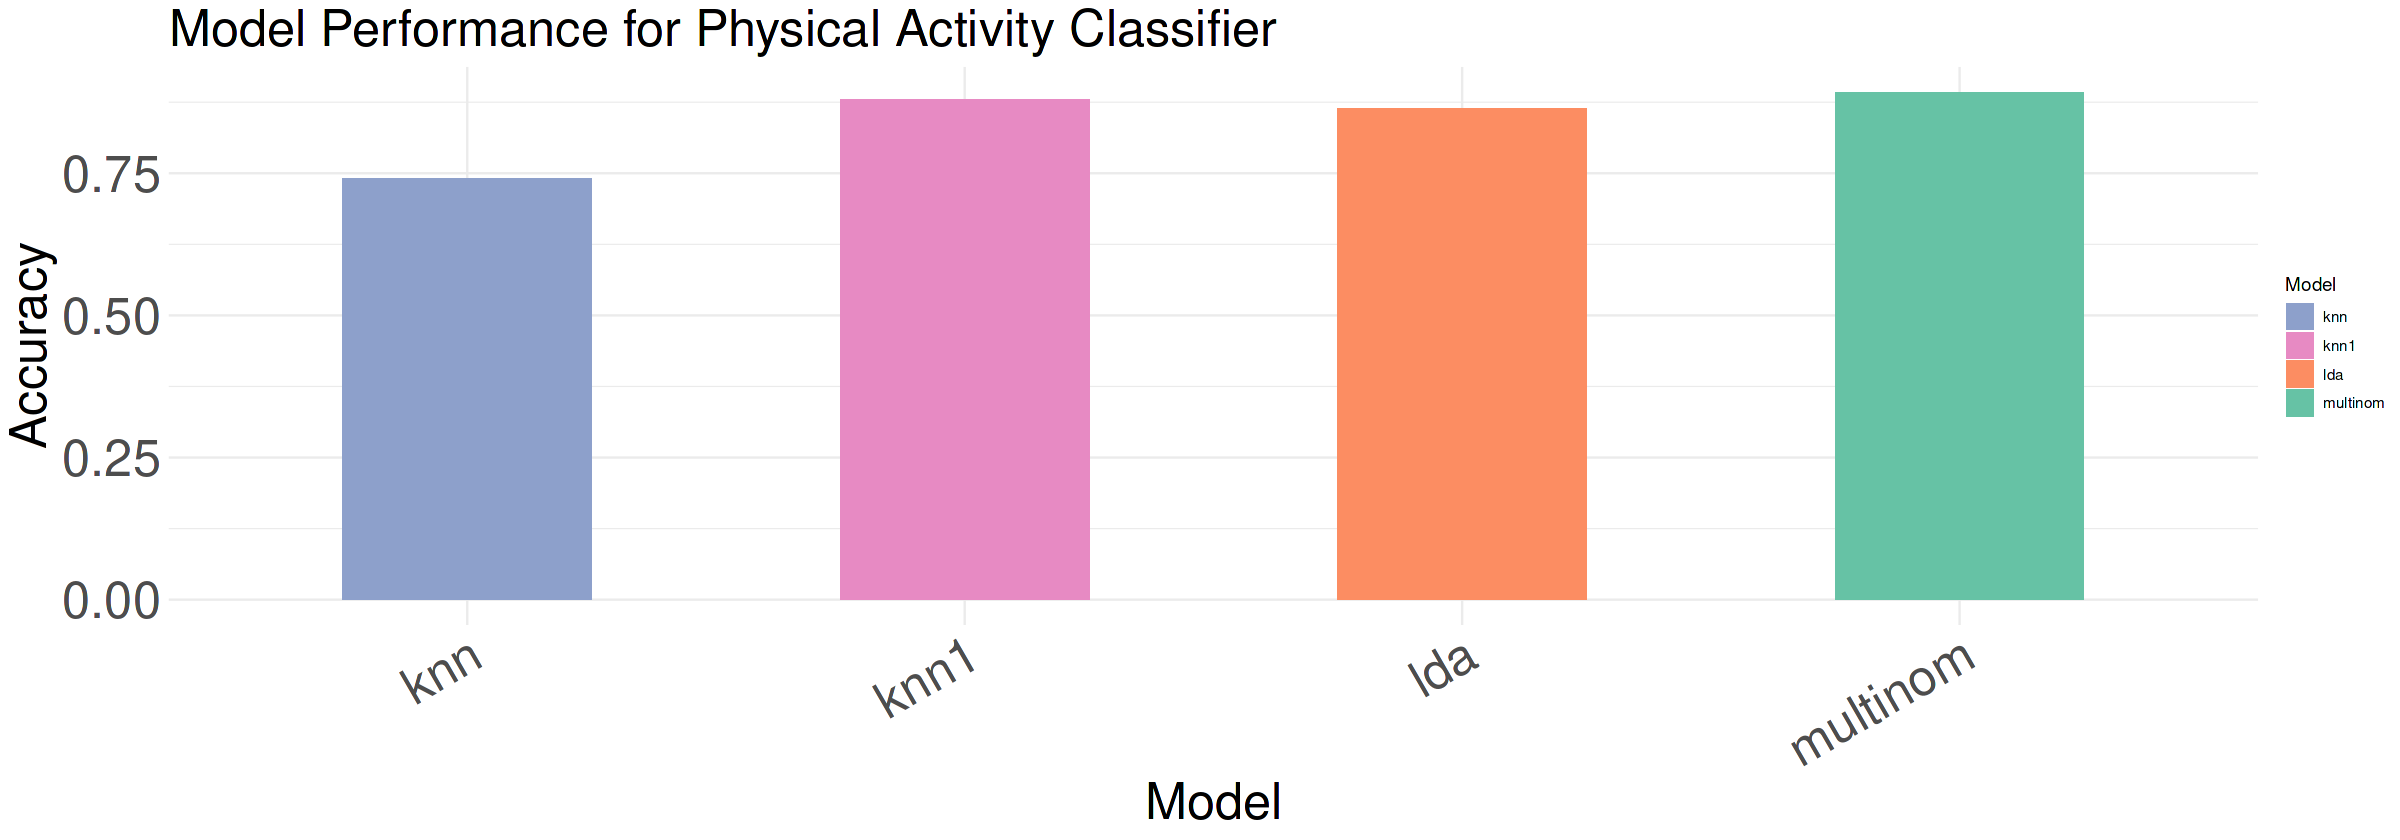

In [96]:
# Create a data frame with model names and accuracy scores
model_names <- c("multinom", "lda", "knn", "knn1")  # Update with your actual model names
Acc <- sapply(list(fit_multinom, fit_lda, fit_knn, fit_KNN1), function(mdl) max(mdl$results$Accuracy))
model_data <- data.frame(Model = model_names, Accuracy = Acc)

# Find the best performing model
best_model <- model_data[which.max(model_data$Accuracy), ]

# Create a bar plot with ggplot2 with pastel blue and green colors, increased font size, and thinner bars
ggplot(model_data, aes(x = Model, y = Accuracy, fill = Model)) +
  geom_bar(stat = "identity", width = 0.5) +  # Adjust the width parameter for thinner bars
  scale_fill_manual(values = c("multinom" = "#66c2a5", "lda" = "#fc8d62", "knn" = "#8da0cb", "knn1" = "#e78ac3")) +  # Specify pastel colors
  labs(title = "Model Performance for Physical Activity Classifier",
       x = "Model",
       y = "Accuracy") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 30), 
        axis.text.y = element_text(size = 30),  
        axis.title = element_text(size = 30),   
        plot.title = element_text(size = 30))


# **5. SUBMISSION**

In this section, we will prepare our predictions and get ready to submit our work to the competition.

**Therefore we will:**
>  * Load our test data
>  * Use our best model to predict the data
>  * Change the data format

## **5.1 PREPARING TEST DATA**

We begin by loading our test data files and then using **map_dfr** again to go through all our the files and add the features we previously created. Then we merge the data and have a look at it.

In [97]:
# Iterate through accelerometer filenames
filenames_test_acc = list.files("./RawData/Test/", "^acc", full.names = TRUE)
test_acc <- map_dfr(filenames_test_acc, extractFeatures, sample_labels) 

# Iterate through gyroscope filenames
filenames_test_gyro = list.files("./RawData/Test/", "^gyro", full.names = TRUE)
test_gyro <- map_dfr(filenames_test_gyro, extractFeatures, sample_labels)

# Merge together
myData_test <-  test_acc %>%
    left_join(test_gyro, 
              by = c("user_id", "exp_id", "activity", "sampleid", "epoch", "n_samples"))

# Take a look
head(myData_test)

epoch,user_id,exp_id,activity,sampleid,m1.x,m2.x,m3.x,mdif1_2.x,mdif1_3.x,⋯,spec_mean_1.y,spec_mean_2.y,spec_mean_3.y,spec_var_1.y,spec_var_2.y,spec_var_3.y,spectral_peak1.y,spectral_peak2.y,spectral_peak3.y,rms_1.y
<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,2,3,-,0,0.1693034,-0.2382921,0.8003690,0.4075955,-0.6310656,⋯,6.649702e-02,8.405664e-02,1.299314e-02,8.140186e-01,2.149156e-01,7.925323e-02,0.0390625,0.0078125,0.0078125,1.00235456
1,2,3,-,128,0.8997071,-0.3948568,-0.2429905,1.2945639,1.1426975,⋯,2.112746e-02,4.620913e-02,2.985326e-02,3.599322e-03,5.963980e-03,6.690383e-02,0.0703125,0.0859375,0.0156250,1.04465051
2,2,3,-,256,0.9974935,-0.2712565,0.1135525,1.2687500,0.8839410,⋯,7.125756e-04,1.885431e-03,4.497974e-04,1.642089e-04,3.012466e-04,9.166789e-05,0.0625000,0.0234375,0.0312500,0.13675246
3,2,3,-,384,0.9928928,-0.2702691,0.1391276,1.2631619,0.8537652,⋯,1.936236e-05,1.576628e-05,1.157673e-05,1.059964e-06,2.485608e-06,1.569735e-06,0.0078125,0.0156250,0.0078125,0.01994949
4,2,3,-,512,0.9908854,-0.2861979,0.1286350,1.2770834,0.8622504,⋯,8.137027e-06,7.494763e-06,6.702299e-06,7.778906e-07,1.065188e-06,7.606784e-07,0.0078125,0.0312500,0.0390625,0.01951123
5,2,3,-,640,0.9909180,-0.2904948,0.1215712,1.2814128,0.8693468,⋯,6.573663e-06,1.111430e-05,1.244990e-05,9.572516e-07,1.402107e-06,1.640208e-06,0.0312500,0.0468750,0.0468750,0.01805453


## **5.2 PREDICTION**

Now we will use our **multinomial logistictic regression** and predict the test data.

In [98]:
# Create a df to use for creating predictions
pred_df <- myData_test %>%
  select(-epoch, -user_id, -exp_id, -sampleid, n_samples)

# We create predictinos based on fit_lda_clean
predictions <- predict(object = fit_multinom, newdata = myData_test[,-1])

# Put the predictions into test_df
myData_test["activity"] <- predictions

# Take a look
head(myData_test)

epoch,user_id,exp_id,activity,sampleid,m1.x,m2.x,m3.x,mdif1_2.x,mdif1_3.x,⋯,spec_mean_1.y,spec_mean_2.y,spec_mean_3.y,spec_var_1.y,spec_var_2.y,spec_var_3.y,spectral_peak1.y,spectral_peak2.y,spectral_peak3.y,rms_1.y
<dbl>,<dbl>,<dbl>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,2,3,LIE_TO_STAND,0,0.1693034,-0.2382921,0.8003690,0.4075955,-0.6310656,⋯,6.649702e-02,8.405664e-02,1.299314e-02,8.140186e-01,2.149156e-01,7.925323e-02,0.0390625,0.0078125,0.0078125,1.00235456
1,2,3,STAND_TO_SIT,128,0.8997071,-0.3948568,-0.2429905,1.2945639,1.1426975,⋯,2.112746e-02,4.620913e-02,2.985326e-02,3.599322e-03,5.963980e-03,6.690383e-02,0.0703125,0.0859375,0.0156250,1.04465051
2,2,3,STANDING,256,0.9974935,-0.2712565,0.1135525,1.2687500,0.8839410,⋯,7.125756e-04,1.885431e-03,4.497974e-04,1.642089e-04,3.012466e-04,9.166789e-05,0.0625000,0.0234375,0.0312500,0.13675246
3,2,3,STANDING,384,0.9928928,-0.2702691,0.1391276,1.2631619,0.8537652,⋯,1.936236e-05,1.576628e-05,1.157673e-05,1.059964e-06,2.485608e-06,1.569735e-06,0.0078125,0.0156250,0.0078125,0.01994949
4,2,3,STANDING,512,0.9908854,-0.2861979,0.1286350,1.2770834,0.8622504,⋯,8.137027e-06,7.494763e-06,6.702299e-06,7.778906e-07,1.065188e-06,7.606784e-07,0.0078125,0.0312500,0.0390625,0.01951123
5,2,3,STANDING,640,0.9909180,-0.2904948,0.1215712,1.2814128,0.8693468,⋯,6.573663e-06,1.111430e-05,1.244990e-05,9.572516e-07,1.402107e-06,1.640208e-06,0.0312500,0.0468750,0.0468750,0.01805453


## **5.3 SUBMISSION FILE**

For this competition we are asked to submit the predictions in a very specific way. Here's how to do that:

In [99]:
# Formating our data for the competition
myData_test %>%

    # Prepend "user" and "exp" to user_id and exp_id
    mutate(
        user_id = paste(ifelse(user_id < 10, "user0", "user"), user_id, sep=""), 
        exp_id = paste(ifelse(exp_id < 10, "exp0", "exp"), exp_id, sep="")
    ) %>% 

     # Unite columns user_id, exp_id and sample_id into a string 
     # Separated by "_" and store it in the new variable `Id`
    unite(Id, user_id, exp_id, sampleid) %>%

    # Retain only the `Id` and  predictions
    select(Id, Predicted = activity) %>%

    # Write to file
    write_csv("submission_final.csv")

# Check the result: print first 20 lines in the submission file
cat(readLines("submission_final.csv",20), sep="\n")

Id,Predicted
user02_exp03_0,LIE_TO_STAND
user02_exp03_128,STAND_TO_SIT
user02_exp03_256,STANDING
user02_exp03_384,STANDING
user02_exp03_512,STANDING
user02_exp03_640,STANDING
user02_exp03_768,STANDING
user02_exp03_896,STANDING
user02_exp03_1024,STANDING
user02_exp03_1152,STANDING
user02_exp03_1280,STANDING
user02_exp03_1408,STANDING
user02_exp03_1536,STANDING
user02_exp03_1664,SITTING
user02_exp03_1792,SITTING
user02_exp03_1920,SITTING
user02_exp03_2048,SITTING
user02_exp03_2176,SITTING
user02_exp03_2304,SITTING


# **6. ACKNOWLEDGMENTS**

The data utilized in this notebook was sourced from the following publication:

> Jorge-L. Reyes-Ortiz, Luca Oneto, Albert Samà, Xavier Parra, Davide Anguita. *Transition-Aware Human Activity Recognition Using Smartphones.* Neurocomputing. Springer, 2015.

**Further References:**
> Grasman, R. (2018). Feature extraction from Signals. Dropbox Paper. https://paper.dropbox.com/doc/Feature-extraction-from-Signals-qCp5uvj47gmyuw5nmB8lL
>
>Webb, G.I. (2011). Occam’s Razor. In: Sammut, C., Webb, G.I. (eds) Encyclopedia of Machine Learning. Springer, Boston, MA. https://doi.org/10.1007/978-0-387-30164-8_609
> 
> Zhu, J., San-Segundo, R. & Pardo, J.M. Feature extraction for robust physical activity recognition. Hum. Cent. Comput. Inf. Sci. 7, 16 (2017). https://doi.org/10.1186/s13673-017-0097-2



# **7. DIVISION OF LABOR**


> **Layout, Design and Text:** Laura
>
> **Feature Extraction:** Yuxuan and Laura
>
> **Model Selection:** Yuxuan and Laura
